In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 


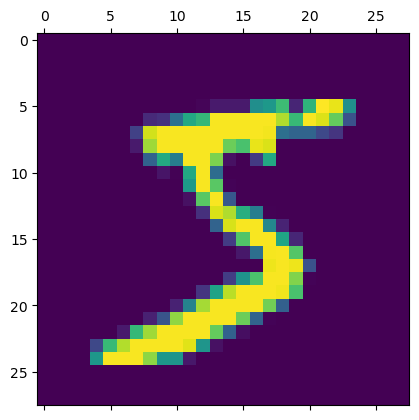

In [3]:
plt.matshow(x_train[0])

In [4]:
# normalize the data(0-1) # [0-255]------> [0 - 1]

x_train = x_train/255.0
x_test = x_test/255.0

In [5]:
# reshape, include the channels  RGB--->Grey Scales
x_train = x_train.reshape(-1,28,28,1)  # -1---len(x_train)
x_test = x_test.reshape(-1,28,28,1)

#Building the model

**Create a Sequential model**

models.Sequential([...])
A simple stack of layers, where the output of one is the input to the next.

**Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))**

Learns 32 filters (feature detectors), each 3×3, scanning the image.

**input_shape=(28,28,1) says “28×28 pixels, 1 channel (grayscale)”.**

relu turns negative values to 0, helping the network learn non-linear patterns.

Output shape: 26×26×32 (because 28−3+1 = 26 with valid padding).

**MaxPooling2D((2,2))**

Takes the max in each 2×2 window, downsampling to reduce size and overfitting; adds a bit of translation invariance.

Output shape: 13×13×32.

**Conv2D(64, (3,3), activation='relu')**

Another conv layer with 64 filters to learn more complex patterns from the previous feature maps.

Output shape: 11×11×64 (13−3+1 = 11).

**MaxPooling2D((2,2))**

Downsamples again.

Output shape: 5×5×64 (floor of 11/2).

**Flatten()**

Converts the 3D tensor to a 1D vector so it can go into fully connected layers.

Output shape: 5×5×64 = 1600 units.

**Dense(64, activation='relu')**

A fully connected layer that mixes all features and learns non-linear combinations.

Output shape: 64.

**Dense(10, activation='softmax')**

Final classification layer for 10 classes.

softmax outputs a probability distribution that sums to 1.

Output shape: 10 (one probability per class).

In [6]:
# Build the CNN model
model = models.Sequential([ layers.Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(64,(3,3),activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(64,activation='relu'),
                           layers.Dense(10,activation='softmax')])

# compile the model
model.compile(optimizer ='adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'] )

C:\Users\91880\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Training
model.fit(x_train, y_train,epochs = 5, validation_data=(x_test,y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f'Test accuracy: {test_acc: .4f}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9574 - loss: 0.1384 - val_accuracy: 0.9795 - val_loss: 0.0610
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9861 - loss: 0.0453 - val_accuracy: 0.9893 - val_loss: 0.0343
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9895 - loss: 0.0313 - val_accuracy: 0.9881 - val_loss: 0.0362
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9929 - loss: 0.0230 - val_accuracy: 0.9901 - val_loss: 0.0286
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9915 - val_loss: 0.0289
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9915 - loss: 0.0289
Test accuracy:  0.9915


In [8]:
x_test[5]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [9]:
# loading an image
from PIL import Image

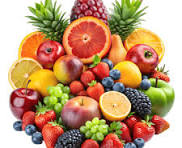

In [12]:
Image.open('fruits.jpeg')

In [14]:
img = Image.open('fruits.jpeg').convert('L') # convert to gray scale

In [15]:
img = img.resize((28,28))

In [16]:
import numpy as np
img_array = np.array(img)

In [17]:
img_array

array([[255, 255, 255, 255, 255, 226, 200, 171, 222, 248, 255, 184,  89,
        105, 120, 169, 252, 223, 192, 152, 172, 175, 250, 254, 255, 255,
        255, 255],
       [255, 255, 255, 255, 218, 159, 150, 159, 181, 237, 249, 127,  97,
         86, 104, 139, 227, 204, 132, 151, 143, 195, 234, 254, 255, 255,
        255, 255],
       [255, 255, 255, 253, 226, 167, 145, 147, 136, 220, 221,  85,  72,
         89,  90, 115, 185, 182, 109, 125, 131, 175, 234, 255, 255, 255,
        255, 255],
       [255, 255, 255, 251, 202, 142, 108,  96,  98, 164, 179,  83, 152,
        164, 155, 112, 127, 117, 100, 100, 119, 186, 248, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 232, 157, 111,  92,  95,  81, 137, 175, 144,
        122, 140, 180, 115,  71,  85,  92, 135, 221, 254, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 221, 129,  82,  63,  64, 157, 136, 112,
        121, 111, 130, 159,  66,  70,  77, 146, 214, 230, 251, 255, 255,
        255, 255],
       [25

In [18]:
img_array = img_array - 255

In [19]:
img_array = img_array/255

In [20]:
input_data = img_array.reshape(1,28,28,1)  #--grey scale

In [21]:
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


array([[0.06639144, 0.18128666, 0.10859015, 0.06909474, 0.06444918,
        0.02210487, 0.2163835 , 0.02803802, 0.24124692, 0.00241455]],
      dtype=float32)

In [22]:
pred = model.predict(input_data)
np.argmax(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


np.int64(8)

In [24]:
img = Image.open('fruits.jpeg').convert('L') # convert to gray scale
img = img.resize((28,28))  #Resizes to 28×28, the input size expected by your CNN.
import numpy as np

'''Converts the PIL image into a NumPy array of pixel values.
Now shape is (28, 28).
Values range from 0 (black) to 255 (white).'''


img_array = np.array(img)

# scale pixels to [0,1] by dividing by 255.

#img_array = 255 - img_array   # invert colors
img_array= img_array - 255
img_array = img_array / 255.0



''' Reshapes from (28,28) → (1,28,28,1).
1 = batch size (predicting one image).
28,28 = image dimensions.
1 = grayscale channel.
This matches the model’s input shape.'''

input_data = img_array.reshape(1,28,28,1)  #--grey scale

pred = model.predict(input_data)

'''Model outputs probabilities for each of the 10 classes (digits 0–9).
pred.shape = (1,10) → 1 row (one image), 10 columns (one probability per class).'''

np.argmax(pred)

#'''argmax returns the index of the largest probability.If the 3rd element is highest, it returns 2.That’s the predicted digit'''

#Image → resize → grayscale → normalize → reshape → CNN → probability distribution → pick max → predicted digit.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


np.int64(8)